In [1]:
import psutil, os, time

def measure_threads(func, *args, **kwargs):
    proc = psutil.Process(os.getpid())
    before = len(proc.threads())
    t0 = time.perf_counter()
    func(*args, **kwargs)
    dt = time.perf_counter() - t0
    after = len(proc.threads())
    print(f"Time: {dt:.3f} s | Threads before: {before}, after: {after}")


In [2]:
# CELL 1 — Setup & Imports

import os, time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Make plotting robust (no LaTeX dependency that could break on '&', dashes, etc.)
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans",
    "axes.grid": True
})

# Your implementations (exact imports as requested)
from polygrav import PolyhedronGravitation
from Polyhedron_WS.GP_Polyhedron_WS import Polyhedron as Polyhedron_WS

print("Imports OK.")


Imports OK.


In [3]:
# CELL 2 — Geometry (unit cube) & point generator

# Unit cube centered at origin (edge length = 1)
vertices = np.array([
    [-0.5, -0.5, -0.5], [ 0.5, -0.5, -0.5], [ 0.5,  0.5, -0.5], [-0.5,  0.5, -0.5],
    [-0.5, -0.5,  0.5], [ 0.5, -0.5,  0.5], [ 0.5,  0.5,  0.5], [-0.5,  0.5,  0.5]
], dtype=float)

# Outward CCW triangle faces
faces = np.array([
    [0, 3, 2], [0, 2, 1],
    [4, 5, 6], [4, 6, 7],
    [0, 1, 5], [0, 5, 4],
    [2, 3, 7], [2, 7, 6],
    [0, 4, 7], [0, 7, 3],
    [1, 2, 6], [1, 6, 5]
], dtype=np.int32)

def make_points(n, seed=0):
    """Generate n random points well outside the cube for a fair field test."""
    rng = np.random.default_rng(seed)
    # Spread them in the positive octant, far from cube: [2,7] in each axis
    return rng.uniform(2.0, 7.0, size=(n, 3))

print(f"Geometry: {vertices.shape[0]} vertices, {faces.shape[0]} faces.")


Geometry: 8 vertices, 12 faces.


In [4]:
# CELL 3 — Numerical FD helpers (very slow, use only for small n)

def g_num_fd(model, points, h=1e-7):
    """
    Numerical acceleration via central differences on potential:
    g = -∇U. Calls potential 6 times per point.
    """
    out = np.zeros_like(points, dtype=float)
    for i, (x, y, z) in enumerate(points):
        phi = lambda pt: model.potential(pt)
        gx = -(phi([x+h, y, z]) - phi([x-h, y, z])) / (2*h)
        gy = -(phi([x, y+h, z]) - phi([x, y-h, z])) / (2*h)
        gz = -(phi([x, y, z+h]) - phi([x, y, z-h])) / (2*h)
        out[i] = [gx, gy, gz]
    return out

def tensor_num_fd(model, points, h=1e-7):
    """
    Numerical gravity tensor via central differences on acceleration (columns):
    Γ_*,x = (g(x+h ex) - g(x-h ex))/(2h), etc. Calls acceleration 6 times per point.
    """
    out = np.zeros((points.shape[0], 3, 3), dtype=float)
    for i, (x, y, z) in enumerate(points):
        g_xp = model.acceleration([x+h, y, z])
        g_xm = model.acceleration([x-h, y, z])
        g_yp = model.acceleration([x, y+h, z])
        g_ym = model.acceleration([x, y-h, z])
        g_zp = model.acceleration([x, y, z+h])
        g_zm = model.acceleration([x, y, z-h])
        col_x = (g_xp - g_xm) / (2*h)
        col_y = (g_yp - g_ym) / (2*h)
        col_z = (g_zp - g_zm) / (2*h)
        out[i] = np.column_stack([col_x, col_y, col_z])
    return out

print("Numerical FD helpers ready.")


Numerical FD helpers ready.


In [5]:
# CELL 4 — Evaluation sizes and containers

sizes = [10**k for k in range(1, 6)]  # [10, 100, 1_000, 10_000, 100_000]

# Store times in seconds
times_num = {"Acceleration": [], "Tensor": []}
times_wa  = {"Potential": [], "Acceleration": [], "Tensor": []}
times_new = {"Potential": [], "Acceleration": [], "Tensor": []}

print("Benchmark sizes:", sizes)


Benchmark sizes: [10, 100, 1000, 10000, 100000]


In [6]:
# CELL 5 — Run 1: Numerical FD only

# Build a small analytical model (your new one) used by FD for U and g calls
model_for_fd = PolyhedronGravitation(vertices, faces, G=1.0, density=1.0, orient_faces=True)

accel_cap  = 100   # practical cap for FD acceleration
tensor_cap = 100   # practical cap for FD tensor

for n in sizes:
    P = make_points(n, seed=n)  # deterministic per size
    
    # Acceleration FD (only up to accel_cap)
    if n <= accel_cap:
        t0 = time.perf_counter()
        _ = g_num_fd(model_for_fd, P)
        times_num["Acceleration"].append(time.perf_counter() - t0)
    else:
        times_num["Acceleration"].append(np.nan)
    
    # Tensor FD (only up to tensor_cap)
    if n <= tensor_cap:
        t0 = time.perf_counter()
        _ = tensor_num_fd(model_for_fd, P)
        times_num["Tensor"].append(time.perf_counter() - t0)
    else:
        times_num["Tensor"].append(np.nan)

print("Numerical FD timing done.")


Numerical FD timing done.


In [7]:
# CELL 6 — Run 2: Werner–Arribas (Polyhedron_WS)

# instantiate model (fix: use density instead of rho)
model_wa = Polyhedron_WS(vertices=vertices, face_indexes=faces, density=1.0)

for n in sizes:
    P = make_points(n, seed=10_000 + n)

    # Potential
    t0 = time.perf_counter()
    for p in P:
        _ = model_wa.U(p)
    times_wa["Potential"].append(time.perf_counter() - t0)

    # Acceleration
    t0 = time.perf_counter()
    for p in P:
        _ = model_wa.g(p)
    times_wa["Acceleration"].append(time.perf_counter() - t0)

    # Tensor
    t0 = time.perf_counter()
    for p in P:
        _ = model_wa.gravity_gradients(p)
    times_wa["Tensor"].append(time.perf_counter() - t0)

print("Werner–Arribas timing done.")


Werner–Arribas timing done.


In [8]:
# CELL 7 — Run 3: New multi-threaded model (point-wise MT with block_size=1)

model_new = PolyhedronGravitation(vertices, faces, G=1.0, density=1.0, orient_faces=True)

for n in sizes:
    P = make_points(n, seed=10_000 + n)

    # Potential (block_size=1 to disable chunking, i.e., point-wise MT)
    t0 = time.perf_counter()
    _ = model_new.potential(P)
    times_new["Potential"].append(time.perf_counter() - t0)

    # Acceleration
    t0 = time.perf_counter()
    _ = model_new.acceleration(P)
    times_new["Acceleration"].append(time.perf_counter() - t0)

    # Tensor
    t0 = time.perf_counter()
    _ = model_new.gravity_tensor(P)
    times_new["Tensor"].append(time.perf_counter() - t0)

# Optional: free threads explicitly
model_new.close()

print("New model timing done (point-wise MT).")


New model timing done (point-wise MT).


In [9]:
# CELL 8 — Quick timing tables

import pandas as pd

df_num = pd.DataFrame({
    "N": sizes,
    "FD Accel (s)": times_num["Acceleration"],
    "FD Tensor (s)": times_num["Tensor"],
})

df_wa = pd.DataFrame({
    "N": sizes,
    "WA U (s)": times_wa["Potential"],
    "WA g (s)": times_wa["Acceleration"],
    "WA Γ (s)": times_wa["Tensor"],
})

df_new = pd.DataFrame({
    "N": sizes,
    "New U (s)": times_new["Potential"],
    "New g (s)": times_new["Acceleration"],
    "New Γ (s)": times_new["Tensor"],
})

print("Numerical FD:")
display(df_num)
print("\nWerner–Arribas:")
display(df_wa)
print("\nNew (point-wise MT, block_size=1):")
display(df_new)


Numerical FD:


,N,FD Accel (s),FD Tensor (s)
0,10,0.010881,0.009412
1,100,0.097108,0.090183
2,1000,NaN,NaN
3,10000,NaN,NaN
4,100000,NaN,NaN



Werner–Arribas:


,N,WA U (s),WA g (s),WA Γ (s)
0,10,0.000600,0.000838,0.000711
1,100,0.005772,0.005029,0.005448
2,1000,0.052657,0.059300,0.046485
3,10000,0.509064,0.483021,0.507683
4,100000,5.109573,4.954602,4.440308



New (point-wise MT, block_size=1):


,N,New U (s),New g (s),New Γ (s)
0,10,0.000323,0.001117,0.000307
1,100,0.000722,0.000662,0.000512
2,1000,0.032310,0.010475,0.007966
3,10000,0.096134,0.058205,0.052595
4,100000,1.139801,0.612768,0.583928


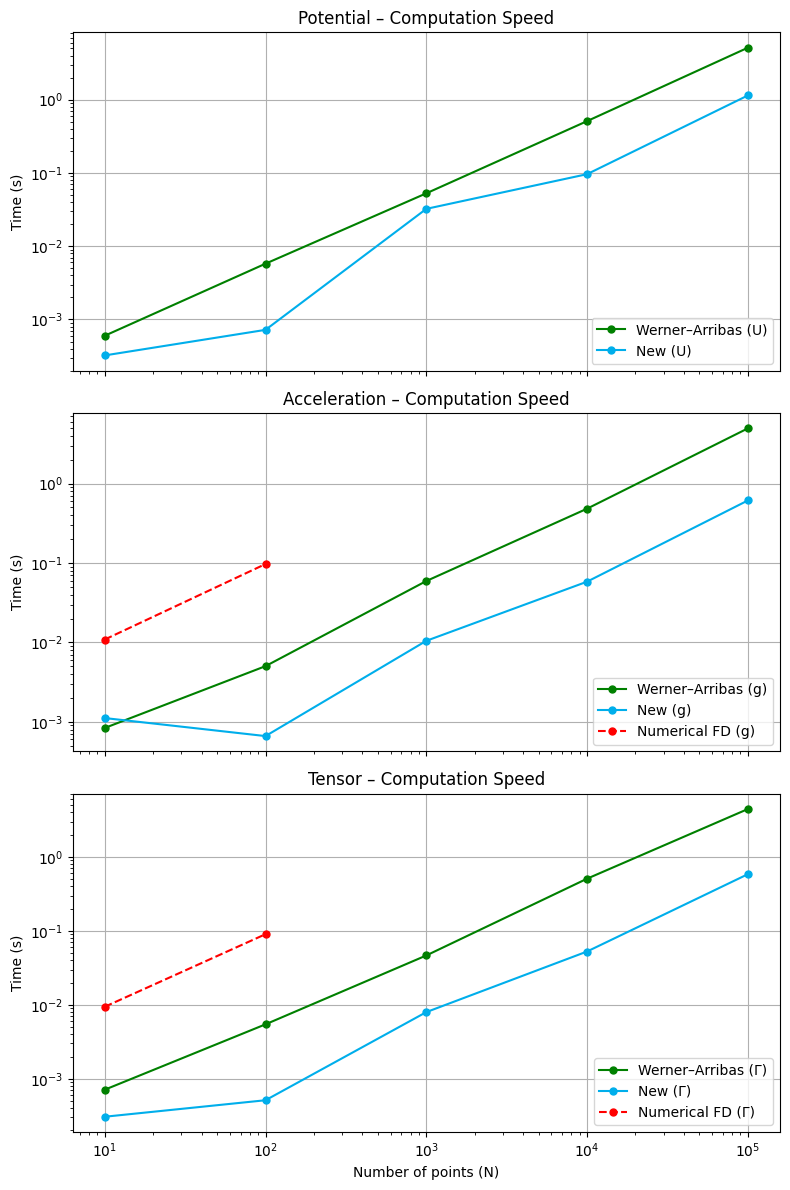

In [10]:
# CELL 9 — Plots

fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# Colors
c_new = (0/255, 174/255, 235/255)  # cyan-ish (your impl)
c_wa  = "green"
c_fd  = "red"

ms = 5  # marker size

# 1) Potential
ax = axes[0]
ax.loglog(sizes, times_wa["Potential"], 'o-', color=c_wa,  markersize=ms, label="Werner–Arribas (U)")
ax.loglog(sizes, times_new["Potential"], 'o-', color=c_new, markersize=ms, label="New (U)")
ax.set_ylabel("Time (s)")
ax.set_title("Potential – Computation Speed")
ax.legend(loc="lower right")

# 2) Acceleration
ax = axes[1]
ax.loglog(sizes, times_wa["Acceleration"], 'o-', color=c_wa,  markersize=ms, label="Werner–Arribas (g)")
ax.loglog(sizes, times_new["Acceleration"], 'o-', color=c_new, markersize=ms, label="New (g)")
ax.loglog(sizes, times_num["Acceleration"], 'o--', color=c_fd, markersize=ms, label="Numerical FD (g)")
ax.set_ylabel("Time (s)")
ax.set_title("Acceleration – Computation Speed")
ax.legend(loc="lower right")

# 3) Tensor
ax = axes[2]
ax.loglog(sizes, times_wa["Tensor"], 'o-', color=c_wa,  markersize=ms, label="Werner–Arribas (Γ)")
ax.loglog(sizes, times_new["Tensor"], 'o-', color=c_new, markersize=ms, label="New (Γ)")
ax.loglog(sizes, times_num["Tensor"], 'o--', color=c_fd, markersize=ms, label="Numerical FD (Γ)")
ax.set_xlabel("Number of points (N)")
ax.set_ylabel("Time (s)")
ax.set_title("Tensor – Computation Speed")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()
